In [4]:
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0) 


Tools


In [15]:
# NEWS Search Tool

from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun(description="A tool to search for information on the internet")

#Wikipedia Tool

from langchain_community.retrievers import WikipediaRetriever

wiki_retriever = WikipediaRetriever()

@tool
def wikipedia_tool(query: str) -> str:
    """Search Wikipedia for information."""
    docs = wiki_retriever.get_relevant_documents(query)

    if not docs:
        return "No Wikipedia results found."

    return docs[0].page_content

#Custom Tool

from langchain.tools import tool

@tool
def enterprise_tool(query: str) -> str:
    """This is a tool to send emails to employees"""

    return "Email sent"


In [16]:
toolkit = [search_tool, wikipedia_tool, enterprise_tool]
toolkit

[DuckDuckGoSearchRun(description='A tool to search for information on the internet', api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text')),
 StructuredTool(name='wikipedia_tool', description='Search Wikipedia for information.', args_schema=<class 'langchain_core.utils.pydantic.wikipedia_tool'>, func=<function wikipedia_tool at 0x0000014A319884A0>),
 StructuredTool(name='enterprise_tool', description='This is a tool to send emails to employees', args_schema=<class 'langchain_core.utils.pydantic.enterprise_tool'>, func=<function enterprise_tool at 0x0000014A31988680>)]

Agent

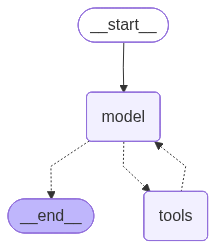

In [17]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0, 
    max_tokens=None,
    timeout=None,
    max_retries=2,
)
agent = create_agent(model, tools=toolkit)
agent

React Agent invoke with Streams

In [18]:
example_query = "Give me the latest news about stock market"

events = agent.stream(
    {"messages": [("user", example_query)]},
    stream_mode="values",
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Give me the latest news about stock market
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (fdd2dc5c-c8f5-4b5d-8d6e-5ae48814ffe2)
 Call ID: fdd2dc5c-c8f5-4b5d-8d6e-5ae48814ffe2
  Args:
    query: latest news about stock market
================================= Tool Message =================================
Name: duckduckgo_search

Yahoo Finance provides thelateststockmarketnews, with the S&P 500 closing at 4,169.48, up 0.83%, the Dow 30 up 0.80%, and the Nasdaq up 84.35 ... Stockmarketnewsis thelatestnewsand informationaboutnot only the Nasdaq and theNewYorkStockExchange, but globalmarkets, emergingmarkets... Investor apprehensionsaboutFriday’s non-farm payroll data dragged benchmarks lower on Thursday. ...Marketsenjoyed a decent rally in the month ... Want thelatestrecommendations from Zacks Investment Research? Today, you can download 7 Be

Manual Binding 

In [20]:
llm.invoke("I want the latest news of stock market that happened just now")

AIMessage(content='As an AI, I don\'t have real-time, second-by-second access to live market data that "just happened." My knowledge cutoff means I can provide you with information up to my last update, which is typically a few hours to a day old.\n\nTo get the absolute latest, "just now" news, you\'ll need to check a live financial news source.\n\n**However, I can give you a summary of the most recent trends and what\'s likely driving the market as of my last update.**\n\n**To get real-time, "just now" updates, I highly recommend checking these sources:**\n\n*   **Bloomberg:** (bloomberg.com)\n*   **Reuters:** (reuters.com/markets)\n*   **The Wall Street Journal:** (wsj.com/markets)\n*   **CNBC:** (cnbc.com)\n*   **Yahoo Finance:** (finance.yahoo.com)\n*   **Google Finance:** (google.com/finance)\n*   **Your brokerage platform:** Most platforms offer live market data and news feeds.\n\nThese sources will provide you with the most up-to-the-minute information on major indices (Dow Jone

In [21]:
llm_binded = llm.bind_tools(toolkit)
llm_binded.invoke("I want the latest news of stock market that happened just now")

AIMessage(content='', additional_kwargs={'function_call': {'name': 'duckduckgo_search', 'arguments': '{"query": "latest stock market news"}'}, '__gemini_function_call_thought_signatures__': {'92fa63af-7489-4461-b2ae-697c157b92df': 'CpIDAb4+9vveJY+kNPmeTC+sE7nkTJ5T7T3WDmZM1oD4qlIk/hB34roLpD4kUFTtNE7XSnmgHmNCllEPe5UQiTotDvYZGB4pBU9A+Nnufy2a+99nb71yQZslgt+QBHn0z+NnvTT+3teEuFHi+2pCd7Mp7z7EH13dTiaMvdXZCTMR+f/kEnheEZte18vANc1baGtnbOaIVwd3MGpuR5c2KaxrFFSIRFFuE9ZQhBi3zdroS78JU8wIctsAAAXSQSoQoR6LKZXcNU3vSunT+JK9yn6yBQhRYTTw9bHbPtmfZP98xphu8Sh9uFclzzYYrWt+MeN9yK8qnfcJV/dz2D8tgtBhGotydw0qOCjrk97/SyNSDU3xvRZhAroiTF8707PXt57Sn19UQC7fJ06iJZl6vHg8SjB4igrCfo8PMTOOsosafcFj7yz2BOlQc34l52ErwwxGfwn5fo6H7vf1xyqZTIsQKcRouYL0qM/RGwpRYNLn5ZSC8kP06BdPQQxzzn9IyKw3oqvdasjxWJy8rawxhn/qg7pi'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ceb05-e1b4-7281-8d5e-559fc2119d59-0', tool_calls=[{'name': 'duckduckgo_se